In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = pd.read_csv(
    r"C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\titanic.csv"
)

print("Dataset shape: ", df.shape)
display(df.head())


Dataset shape:  (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:

print("\nData types:", df.dtypes)


print("\nDuplicate rows:", df.duplicated().sum())


Data types: PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Duplicate rows: 0


In [4]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Rows before removing duplicates: ", rows_before)
print("Rows after removing duplicates: ", rows_after)
print("Number of duplicate rows removed: ", rows_before - rows_after)

Rows before removing duplicates:  891
Rows after removing duplicates:  891
Number of duplicate rows removed:  0


In [5]:
# PassengerId is only an identifier, Name and Ticket are free text with (almost)
# one unique value per passenger, and Cabin is ~77% missing.
# None of them is a useful model feature, so they are dropped with the target.
x = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
y = df["Survived"]

print("X shape: ", x.shape)
print("y shape: ", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape:  (891, 7)
y shape:  (891,)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Training percentage:", len(X_train) / len(x) * 100)
print("Testing percentage :", len(X_test) / len(x) * 100)

Training rows: 712
Testing rows : 179
Training percentage: 79.91021324354658
Testing percentage : 20.089786756453424


In [7]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical coloumns: ", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns: ", len(categorical_cols))
print(categorical_cols)

Numerical coloumns:  5
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns:  2
['Sex', 'Embarked']


In [8]:
missing_count = X_train.isna().sum()
missing_percent = X_train.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %" : missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

display(missing_summary)

,Missing Count,Missing %
Age,137,19.241573
Embarked,2,0.280899


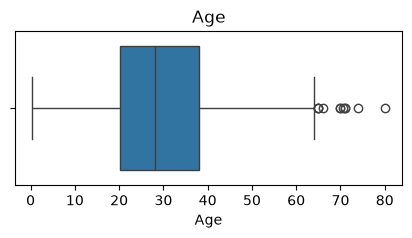

In [9]:
missing_cols=missing_summary.index.tolist()

# Boxplots are only meaningful for numerical columns (Embarked is categorical)
missing_numeric_cols = [col for col in missing_cols if col in numeric_cols]

for col in missing_numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

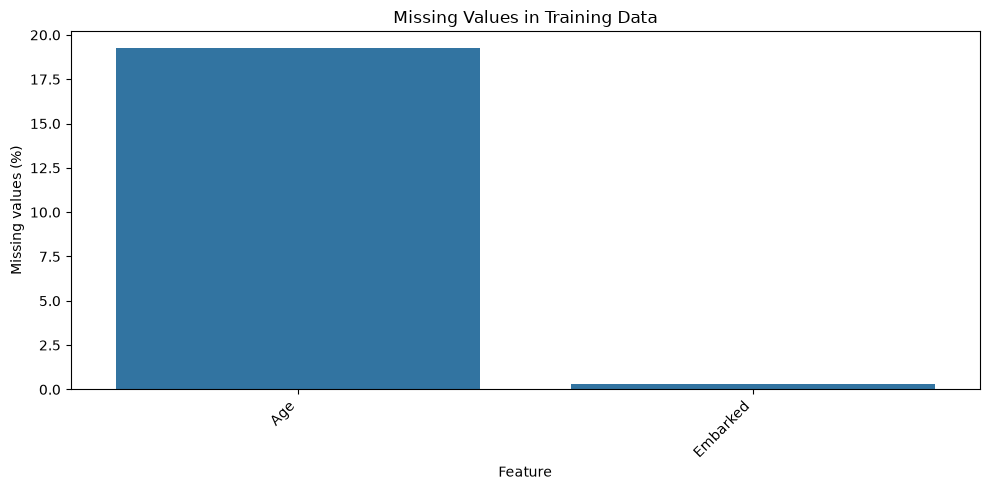

In [10]:

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing %"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Missing values (%)")
plt.title("Missing Values in Training Data")
plt.tight_layout()
plt.show()

In [11]:
rows_before = len(X_train)

X_train_without_missing = X_train.dropna()

rows_after = len(X_train_without_missing)

loss = rows_before - rows_after
loss_percent = loss / rows_before * 100

print("Rows before deletion:", rows_before)
print("Rows after deletion :", rows_after)
print("Rows lost           :", loss)
print("Percentage lost     :", round(loss_percent, 2), "%")

Rows before deletion: 712
Rows after deletion : 573
Rows lost           : 139
Percentage lost     : 19.52 %


In [12]:
X_train.shape

(712, 7)

In [13]:
numeric_imputer = SimpleImputer(strategy="median")

# STEP 1: Learn medians ONLY from training data
X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

# STEP 2: Apply the SAME training medians to test data
X_test_num = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Missing numerical values after imputation:")
print("Training:", X_train_num.isna().sum().sum())
print("Test    :", X_test_num.isna().sum().sum())

Missing numerical values after imputation:
Training: 0
Test    : 0


In [14]:
X_train_num.shape

(712, 5)

In [15]:
missing_numeric_cols = [
    col for col in numeric_cols
    if X_train[col].isna().any()
]

print("Numerical columns with missing values:")
print(missing_numeric_cols)

for col in missing_numeric_cols:
    X_train_num[col + "_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test_num[col + "_missing"] = (
        X_test[col].isna().astype(int)
    )

print("\nMissing indicators created.") 

Numerical columns with missing values:
['Age']

Missing indicators created.


In [16]:
X_train_num

,Pclass,Age,SibSp,Parch,Fare,Age_missing
692,3.0,28.5,0.0,0.0,56.4958,1
481,2.0,28.5,0.0,0.0,0.0000,1
527,1.0,28.5,0.0,0.0,221.7792,1
855,3.0,18.0,0.0,1.0,9.3500,0
801,2.0,31.0,1.0,1.0,26.2500,0
...,...,...,...,...,...,...
359,3.0,28.5,0.0,0.0,7.8792,1
258,1.0,35.0,0.0,0.0,512.3292,0
736,3.0,48.0,1.0,3.0,34.3750,0
462,1.0,47.0,0.0,0.0,38.5000,0


In [17]:
X_train_num.shape

(712, 6)

In [18]:
# Pclass is already numeric (1, 2, 3) and is handled with the numerical
# columns, so there are no ordered text columns in this dataset.
ordinal_cols = []

# All remaining categorical columns are treated as nominal.
nominal_cols = [
    col for col in categorical_cols
    if col not in ordinal_cols
]

print("Ordinal columns:")
print(ordinal_cols)

print("\nNominal columns:")
print(nominal_cols)

Ordinal columns:
[]

Nominal columns:
['Sex', 'Embarked']


In [19]:
for col in nominal_cols:
    print(f"\n{col}")
    print(X_train[col].unique())


Sex
<StringArray>
['male', 'female']
Length: 2, dtype: str

Embarked
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [20]:
if ordinal_cols:
    ordinal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_ord = pd.DataFrame(
        ordinal_imputer.fit_transform(X_train[ordinal_cols]),
        columns=ordinal_cols,
        index=X_train.index
    )

    X_test_ord = pd.DataFrame(
        ordinal_imputer.transform(X_test[ordinal_cols]),
        columns=ordinal_cols,
        index=X_test.index
    )
else:
    X_train_ord = pd.DataFrame(index=X_train.index)
    X_test_ord = pd.DataFrame(index=X_test.index)


# ----- Nominal columns -----
if nominal_cols:
    nominal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_nom = pd.DataFrame(
        nominal_imputer.fit_transform(X_train[nominal_cols]),
        columns=nominal_cols,
        index=X_train.index
    )

    X_test_nom = pd.DataFrame(
        nominal_imputer.transform(X_test[nominal_cols]),
        columns=nominal_cols,
        index=X_test.index
    )
else:
    X_train_nom = pd.DataFrame(index=X_train.index)
    X_test_nom = pd.DataFrame(index=X_test.index)

print("Categorical imputation completed.")


Categorical imputation completed.


In [21]:
from sklearn.preprocessing import OneHotEncoder

# Drop the first category of EACH nominal variable.
# This gives K-1 dummy variables for a variable having K categories.
# It helps avoid the dummy-variable trap / perfect multicollinearity.

nominal_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# ------------------------------------------------------------
# FIT ON X_train (imputed) AND TRANSFORM X_train
# ------------------------------------------------------------

nominal_encoded_train = nominal_encoder.fit_transform(
    X_train_nom
)

nominal_feature_names = (
    nominal_encoder.get_feature_names_out(nominal_cols)
)

nominal_encoded_train = pd.DataFrame(
    nominal_encoded_train,
    columns=nominal_feature_names,
    index=X_train.index
)

print("\nOne-hot encoded X_train:")
display(nominal_encoded_train.head())

print("\nEncoded nominal feature names:")
print(nominal_feature_names.tolist())

print("\nNumber of nominal features after encoding:",
      nominal_encoded_train.shape[1])


# ------------------------------------------------------------
# TRANSFORM X_test (imputed) USING THE SAME ENCODER
# ------------------------------------------------------------

nominal_encoded_test = nominal_encoder.transform(
    X_test_nom
)

nominal_encoded_test = pd.DataFrame(
    nominal_encoded_test,
    columns=nominal_feature_names,
    index=X_test.index
)

print("\nOne-hot encoded X_test:")
display(nominal_encoded_test.head())

print("\nX_train nominal encoded shape:",
      nominal_encoded_train.shape)

print("X_test nominal encoded shape:",
      nominal_encoded_test.shape)


One-hot encoded X_train:


,Sex_male,Embarked_Q,Embarked_S
692,1.0,0.0,1.0
481,1.0,0.0,1.0
527,1.0,0.0,1.0
855,0.0,0.0,1.0
801,0.0,0.0,1.0



Encoded nominal feature names:
['Sex_male', 'Embarked_Q', 'Embarked_S']

Number of nominal features after encoding: 3

One-hot encoded X_test:


,Sex_male,Embarked_Q,Embarked_S
565,1.0,0.0,1.0
160,1.0,0.0,1.0
553,1.0,0.0,0.0
860,1.0,0.0,1.0
241,0.0,1.0,0.0



X_train nominal encoded shape: (712, 3)
X_test nominal encoded shape: (179, 3)


In [22]:
nominal_encoded_train.shape

(712, 3)

In [23]:
label_encoder = LabelEncoder()

# Learn target mapping from training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Apply the same mapping to test labels
y_test_encoded = label_encoder.transform(y_test)

print("Original target classes:")
print(label_encoder.classes_)

print("\nEncoded target values:")
print(np.unique(y_train_encoded))

Original target classes:
[0 1]

Encoded target values:
[0 1]


In [24]:
X_train_num.shape


(712, 6)

In [25]:
X_train_ord.shape       


(712, 0)

In [26]:
nominal_encoded_train.shape

(712, 3)

In [27]:
X_train_processed = pd.concat(
    [
        X_train_num,
        X_train_ord,        
        nominal_encoded_train

    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_num,
        X_test_ord,        
        nominal_encoded_test
    ],
    axis=1
)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape :", X_test_processed.shape)

X_train processed shape: (712, 9)
X_test processed shape : (179, 9)


In [28]:
scale_cols = [
    col for col in numeric_cols
    if col in X_train_processed.columns
]

scaler = StandardScaler()

# LEARN mean and standard deviation from training data only
X_train_processed[scale_cols] = scaler.fit_transform(
    X_train_processed[scale_cols]
)

# APPLY the same training statistics to test data
X_test_processed[scale_cols] = scaler.transform(
    X_test_processed[scale_cols]
)

print("Standard scaling completed.")

Standard scaling completed.


In [29]:
feature_names = X_train_processed.columns.tolist()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of features: 9

Feature names:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Sex_male', 'Embarked_Q', 'Embarked_S']
